# Task 4 — Final test: Experiment 3b on Jan–May 2026

This notebook performs the **one-time final evaluation** of the frozen
Experiment 3b specification.

Development design:

- 2024: original training year
- 2025: development / validation year
- Jan–May 2026: untouched final test period

Experiment 3b uses schedule, calendar, weather, scheduled-demand, leakage-safe
historical priors, leakage-safe recent operating rates, and the engineered
`national_delay_pressure_7d_vs_28d` feature.

The final model is retrained on **2024–2025 combined**. The 2025 validation
results are used only to freeze the model specification, number of boosting
rounds, and operating threshold. **2026 is never used for model selection,
early stopping, feature selection, hyperparameter tuning, or threshold tuning.**

Recent-performance features preserve the same online information boundary used
in Experiment 3b: for a flight on date `D`, a two-day availability lag means
the newest outcome date that may enter a recent rate is `D - 2`. Therefore,
later 2026 flights may use sufficiently old 2026 outcomes, matching a daily
operational system.

In [9]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier

repo_root = Path("..") if Path("../src").exists() else Path(".")
repo_root = repo_root.resolve()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root / "src"))

from clean_data import load_split, select_arrival_target_rows
from features import (
    DEST_WEATHER_COLS,
    ORIGIN_WEATHER_COLS,
    add_destination_departure_keys,
    add_holiday_features,
    add_schedule_demand,
    add_weather_features,
    build_airport_timezone_lookup,
    load_airport_coordinates,
    scheduled_departure_timestamp,
)
from historical_features import (
    DEFAULT_HISTORICAL_RATE_SPECS,
    add_expanding_historical_rates,
    apply_historical_rate_state,
    fit_historical_rate_state,
    historical_feature_names,
)
from recent_performance_features import (
    DEFAULT_NATIONAL_WINDOWS,
    DEFAULT_RECENT_GROUP_SPECS,
    add_recent_rates_to_splits,
    recent_feature_names,
)

FIGURES = Path("figures")
MODELS = Path("models")
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_YEARS = (2024, 2025)
TEST_YEAR = 2026
TEST_MONTHS = (1, 2, 3, 4, 5)
AVAILABILITY_LAG_DAYS = 2
INITIAL_HISTORICAL_PRIOR = 0.20
INITIAL_RECENT_RATE_PRIOR = 0.20

DEVELOPMENT_MODEL_NAME = "stage1_xgb_2024_to_2025_03b"
FINAL_MODEL_NAME = "stage1_xgb_2024_2025_to_2026_03b_final"

## 1. Load the frozen Experiment 3b specification

The final retrain must not use 2026 for early stopping. Instead, the number of
boosting rounds is frozen from Experiment 3b's best 2025 validation iteration.
The diagnostic operating threshold is also frozen from 2025.

If hyperparameter tuning changes the Experiment 3b settings, update
`FINAL_XGB_PARAMS` before running the final test.

In [10]:
development_metadata_path = MODELS / f"{DEVELOPMENT_MODEL_NAME}_metadata.json"
if not development_metadata_path.exists():
    raise FileNotFoundError(
        f"Missing {development_metadata_path}. Run the frozen Experiment 3b "
        "development notebook first."
    )

development_metadata = json.loads(development_metadata_path.read_text())
frozen_best_iteration = int(development_metadata["best_iteration"])
frozen_n_estimators = frozen_best_iteration + 1
frozen_threshold = float(development_metadata["diagnostic_f1_threshold"])
frozen_features = list(development_metadata["features"])
frozen_validation_metrics = pd.Series(
    development_metadata["validation_metrics"],
    name="2025 validation",
    dtype="float64",
)

FINAL_XGB_PARAMS: dict[str, object] = {
    "objective": "binary:logistic",
    "n_estimators": frozen_n_estimators,
    "learning_rate": 0.05,
    "max_depth": 8,
    "min_child_weight": 20,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 5.0,
    "max_bin": 256,
    "tree_method": "hist",
    "enable_categorical": True,
    "max_cat_to_onehot": 16,
    "eval_metric": ["logloss", "aucpr"],
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

print(f"Frozen best iteration : {frozen_best_iteration}")
print(f"Final n_estimators     : {frozen_n_estimators}")
print(f"Frozen 2025 threshold : {frozen_threshold:.3f}")
print("\nFrozen 2025 validation metrics:")
print(frozen_validation_metrics.round(5).to_string())

Frozen best iteration : 257
Final n_estimators     : 258
Frozen 2025 threshold : 0.217

Frozen 2025 validation metrics:
PR_AUC                    0.42496
ROC_AUC                   0.70318
log_loss                  0.48472
Brier                     0.15695
ECE_10                    0.00956
delay_capture_top10pct    0.22551


## 2. Final-test guardrail

Keep this `False` while tuning. Set it to `True` only after the feature set,
hyperparameters, and threshold are frozen. The 2026 split is not loaded before
this guard is passed.

In [11]:
RUN_FINAL_TEST = True

if not RUN_FINAL_TEST:
    raise RuntimeError(
        "Final 2026 test is intentionally locked. Freeze the Experiment 3b "
        "feature set, hyperparameters, and threshold, then set RUN_FINAL_TEST=True."
    )

## 3. Load 2024–2025 retraining data and Jan–May 2026 test data

Scheduled rows are loaded before model eligibility is applied because scheduled
demand features must include flights that are later cancelled or diverted.

In [12]:
BTS_COLS = [
    "Year", "Month", "DayOfWeek", "DayofMonth", "FlightDate",
    "Reporting_Airline", "Origin", "Dest", "CRSDepTime",
    "CRSElapsedTime", "Distance", "ArrDel15", "Cancelled",
    "Diverted", "DivReachedDest", "DivArrDelay",
]

train_2024_raw = load_split("train", columns=BTS_COLS, model_only=False)
train_2025_raw = load_split("val", columns=BTS_COLS, model_only=False)
test_raw = load_split("test", columns=BTS_COLS, model_only=False)

final_train_raw = pd.concat(
    [train_2024_raw, train_2025_raw],
    ignore_index=True,
    sort=False,
)
del train_2024_raw, train_2025_raw

train_years_found = set(pd.to_numeric(final_train_raw["Year"], errors="raise").unique())
test_years_found = set(pd.to_numeric(test_raw["Year"], errors="raise").unique())
test_months_found = set(pd.to_numeric(test_raw["Month"], errors="raise").unique())

if train_years_found != set(TRAIN_YEARS):
    raise AssertionError(f"Unexpected final-training years: {sorted(train_years_found)}")
if test_years_found != {TEST_YEAR}:
    raise AssertionError(f"Unexpected test years: {sorted(test_years_found)}")
if test_months_found != set(TEST_MONTHS):
    raise AssertionError(f"Unexpected 2026 test months: {sorted(test_months_found)}")

print(f"2024–2025 scheduled rows: {len(final_train_raw):,}")
print(f"Jan–May 2026 scheduled rows: {len(test_raw):,}")

2024–2025 scheduled rows: 14,080,680
Jan–May 2026 scheduled rows: 2,880,796


## 4. Build the leakage-safe feature tables

Static historical features for final-training rows remain past-only: each month
uses outcomes from strictly earlier months. The frozen 2026 historical mapping
is then fitted on all eligible 2024–2025 rows.

Recent rates are computed across the ordered 2024–2026 timeline with the same
two-day availability lag as Experiment 3b. Test outcomes can affect only later
test dates after that lag; they never affect the fitted model.

In [13]:
weather_path = Path("data/interim/weather_hourly.parquet")
wx = pd.read_parquet(weather_path)
wx["hour"] = pd.to_datetime(wx["hour"], errors="coerce")
if wx["hour"].isna().any():
    raise ValueError("weather_hourly.parquet contains invalid hours")
wx = wx[wx["hour"].dt.year.between(min(TRAIN_YEARS), TEST_YEAR)].copy()
if wx.duplicated(["airport", "hour"]).any():
    raise ValueError("Weather table has duplicate airport-hour rows")

weather_cols = list(dict.fromkeys([
    "airport", "hour", "observation_time_local", "weather_observation_missing",
    *ORIGIN_WEATHER_COLS, *DEST_WEATHER_COLS,
]))
wx = wx[[column for column in weather_cols if column in wx.columns]]

coords = load_airport_coordinates()
timezone_lookup = build_airport_timezone_lookup(coords)


def prepare_period(raw: pd.DataFrame) -> pd.DataFrame:
    """Build one leakage-safe Stage 1 model table from scheduled flight rows."""
    n_raw = len(raw)
    keyed = add_destination_departure_keys(raw, timezone_lookup)
    model = select_arrival_target_rows(keyed)
    model["FlightDate"] = pd.to_datetime(model["FlightDate"]).dt.normalize()

    dep_ts = scheduled_departure_timestamp(model)
    model["sched_dep_hour"] = dep_ts.dt.hour.astype("int8")
    model["sched_dep_minute"] = dep_ts.dt.minute.astype("int8")
    model = add_holiday_features(model)
    model = add_schedule_demand(keyed, model)
    model = add_weather_features(
        model,
        wx,
        join_destination=True,
        dest_departure_hour_col="dest_departure_hour_local",
        dest_departure_time_col="dest_departure_time_local",
    )

    if len(model) > n_raw:
        raise AssertionError("Feature construction multiplied flight rows")
    for column in ("origin_weather_age_minutes", "dest_weather_age_minutes"):
        if column in model and model[column].dropna().lt(0).any():
            raise AssertionError(f"{column} contains future weather")

    return model.reset_index(drop=True)


final_train = prepare_period(final_train_raw)
test = prepare_period(test_raw)
del final_train_raw, test_raw, wx

if pd.to_datetime(final_train["FlightDate"]).max() >= pd.to_datetime(test["FlightDate"]).min():
    raise AssertionError("Final training and test date ranges overlap")

# Past-only historical features for 2024–2025 training rows.
final_train_with_history = add_expanding_historical_rates(
    final_train,
    DEFAULT_HISTORICAL_RATE_SPECS,
    initial_prior=INITIAL_HISTORICAL_PRIOR,
)

# Frozen historical mapping for 2026, fitted on all completed 2024–2025 outcomes.
historical_state = fit_historical_rate_state(
    final_train,
    DEFAULT_HISTORICAL_RATE_SPECS,
)
test_with_history = apply_historical_rate_state(test, historical_state)
del final_train, test

# Online recent-rate construction across final train -> final test.
final_train, test = add_recent_rates_to_splits(
    final_train_with_history,
    test_with_history,
    initial_prior=INITIAL_RECENT_RATE_PRIOR,
    availability_lag_days=AVAILABILITY_LAG_DAYS,
)
del final_train_with_history, test_with_history

HISTORICAL_FEATURES = historical_feature_names(DEFAULT_HISTORICAL_RATE_SPECS)
RECENT_FEATURES = recent_feature_names()
PRESSURE_FEATURE = "national_delay_pressure_7d_vs_28d"
PRESSURE_FEATURES = [PRESSURE_FEATURE]

for frame in (final_train, test):
    frame[PRESSURE_FEATURE] = (
        frame["national_delay_rate_7d"]
        - frame["national_delay_rate_28d"]
    ).astype("float32")

for frame_name, frame in (("final_train", final_train), ("test", test)):
    if frame[HISTORICAL_FEATURES].isna().any().any():
        raise AssertionError(f"Missing historical-rate values in {frame_name}")
    if frame[RECENT_FEATURES].isna().any().any():
        raise AssertionError(f"Missing recent-rate values in {frame_name}")
    if frame[PRESSURE_FEATURES].isna().any().any():
        raise AssertionError(f"Missing pressure-feature values in {frame_name}")
    if ((frame[RECENT_FEATURES] < 0) | (frame[RECENT_FEATURES] > 1)).any().any():
        raise AssertionError(f"Recent-rate values outside [0, 1] in {frame_name}")
    if not frame[PRESSURE_FEATURE].between(-1, 1).all():
        raise AssertionError(f"{PRESSURE_FEATURE} outside [-1, 1] in {frame_name}")

print(f"Final-training rows: {len(final_train):,} | delayed: {final_train['ArrDel15'].mean():.1%}")
print(f"Final-test rows    : {len(test):,} | delayed: {test['ArrDel15'].mean():.1%}")

  weather joined: 13,878,218 rows | origin weather missing 0.1%
  weather joined: 2,813,806 rows | origin weather missing 0.8%
Final-training rows: 13,878,218 | delayed: 21.7%
Final-test rows    : 2,813,806 | delayed: 21.5%


## 5. Freeze the Experiment 3b feature contract

Categories are learned from the complete 2024–2025 retraining period. Any new
2026 category is mapped to `__UNSEEN__` only after all joins and target-derived
feature construction that require the original codes.

In [14]:
SCHEDULE_FEATURES = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek", "DayofMonth",
    "sched_dep_hour", "sched_dep_minute", "CRSElapsedTime", "Distance",
]
HOLIDAY_FEATURES = [
    "days_to_next_holiday", "days_since_prev_holiday",
    "next_holiday_name", "prev_holiday_name",
]
WEATHER_FEATURES = [
    *[f"origin_{column}" for column in ORIGIN_WEATHER_COLS],
    *[f"dest_{column}" for column in DEST_WEATHER_COLS],
    "origin_weather_age_minutes", "dest_weather_age_minutes",
    "origin_weather_observation_missing", "dest_weather_observation_missing",
]
DEMAND_FEATURES = [
    "origin_sched_deps_this_hour",
    "origin_sched_ops_this_hour",
    "dest_sched_arrivals_this_hour",
]
FEATURES = (
    SCHEDULE_FEATURES
    + HOLIDAY_FEATURES
    + WEATHER_FEATURES
    + DEMAND_FEATURES
    + HISTORICAL_FEATURES
    + RECENT_FEATURES
    + PRESSURE_FEATURES
)
CATEGORICAL = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek",
    "next_holiday_name", "prev_holiday_name",
    "origin_flight_category", "dest_flight_category",
]

if FEATURES != frozen_features:
    missing_from_final = [feature for feature in frozen_features if feature not in FEATURES]
    added_in_final = [feature for feature in FEATURES if feature not in frozen_features]
    raise AssertionError(
        "Final feature contract differs from frozen Experiment 3b. "
        f"missing={missing_from_final}, added={added_in_final}"
    )

LEAKAGE_FIELDS = {
    "DepTime", "DepDelay", "DepDel15", "TaxiOut", "WheelsOff", "WheelsOn",
    "ArrTime", "ArrDelay", "ArrDelayMinutes", "ActualElapsedTime", "Cancelled",
    "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay",
}
if LEAKAGE_FIELDS.intersection(FEATURES):
    raise AssertionError(
        f"Post-cutoff fields entered FEATURES: {sorted(LEAKAGE_FIELDS.intersection(FEATURES))}"
    )

def align_categories(
    train_x: pd.DataFrame,
    test_x: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int], dict[str, list[str]]]:
    """Learn category levels from 2024–2025 and map unseen 2026 values."""
    train_x = train_x.copy()
    test_x = test_x.copy()
    unseen_counts: dict[str, int] = {}
    category_levels: dict[str, list[str]] = {}

    for column in CATEGORICAL:
        train_values = train_x[column].astype("string").fillna("__MISSING__")
        test_values = test_x[column].astype("string").fillna("__MISSING__")
        known = set(train_values.unique())
        test_values = test_values.where(test_values.isin(known), "__UNSEEN__")
        levels = sorted(known | {"__UNSEEN__"})

        train_x[column] = pd.Categorical(train_values, categories=levels)
        test_x[column] = pd.Categorical(test_values, categories=levels)
        unseen_counts[column] = int(test_values.eq("__UNSEEN__").sum())
        category_levels[column] = levels

    numeric = [column for column in FEATURES if column not in CATEGORICAL]
    for frame in (train_x, test_x):
        frame[numeric] = (
            frame[numeric]
            .apply(pd.to_numeric, errors="coerce")
            .astype("float32")
        )
        if np.isinf(frame[numeric].to_numpy()).any():
            raise ValueError("Infinite numeric feature values found")

    return train_x, test_x, unseen_counts, category_levels

X_train, X_test, unseen_counts, category_levels = align_categories(
    final_train[FEATURES],
    test[FEATURES],
)
y_train = final_train["ArrDel15"].astype("int8").reset_index(drop=True)
y_test = test["ArrDel15"].astype("int8").reset_index(drop=True)

test_meta = test[
    ["FlightDate", "Month", "Reporting_Airline", "Origin", "Dest"]
].reset_index(drop=True).copy()

del final_train, test

print(f"Features: {len(FEATURES)} ({len(CATEGORICAL)} categorical)")
print("Unseen 2026 categories relative to 2024–2025:")
for column, count in unseen_counts.items():
    print(f"{column:35s} {count:>8,}")

Features: 55 (9 categorical)
Unseen 2026 categories relative to 2024–2025:
  Reporting_Airline                          0
  Origin                                   713
  Dest                                     715
  Month                                      0
  DayOfWeek                                  0
  next_holiday_name                          0
  prev_holiday_name                          0
  origin_flight_category                     0
  dest_flight_category                       0


## 6. Retrain Experiment 3b on 2024–2025

There is deliberately **no 2026 `eval_set` and no early stopping** here. The
boosting-round count was already selected on 2025 and is now frozen.

In [15]:
final_model = XGBClassifier(**FINAL_XGB_PARAMS)
final_model.fit(X_train, y_train, verbose=False)
p_test = final_model.predict_proba(X_test)[:, 1]

print(f"Final model fitted with {frozen_n_estimators:,} trees")

Final model fitted with 258 trees


## 7. One-time 2026 final-test metrics

These metrics are for reporting only. Do not use them to change the feature set,
model hyperparameters, number of trees, or decision threshold.

In [16]:
def expected_calibration_error(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Match Experiment 3b's 10-quantile-bin ECE definition."""
    table = pd.DataFrame({"y": np.asarray(y), "p": np.asarray(probabilities)})
    table["bin"] = pd.qcut(table["p"], q=bins, duplicates="drop")
    grouped = table.groupby("bin", observed=True).agg(
        n=("y", "size"),
        actual=("y", "mean"),
        predicted=("p", "mean"),
    )
    return float(
        np.average(
            (grouped["actual"] - grouped["predicted"]).abs(),
            weights=grouped["n"],
        )
    )


def capture_at_fraction(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    fraction: float,
) -> float:
    n = max(1, int(np.ceil(len(y) * fraction)))
    idx = np.argpartition(np.asarray(probabilities), -n)[-n:]
    positives = np.asarray(y).sum()
    return float(np.asarray(y)[idx].sum() / positives) if positives else np.nan


def metric_row(
    name: str,
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    *,
    ece_override: float | None = None,
) -> dict[str, str | float]:
    return {
        "model": name,
        "PR_AUC": average_precision_score(y, probabilities),
        "ROC_AUC": roc_auc_score(y, probabilities),
        "log_loss": log_loss(y, probabilities, labels=[0, 1]),
        "Brier": brier_score_loss(y, probabilities),
        "ECE_10": (
            expected_calibration_error(y, probabilities)
            if ece_override is None
            else ece_override
        ),
        "delay_capture_top10pct": capture_at_fraction(y, probabilities, 0.10),
    }


train_prevalence = float(y_train.mean())
test_prevalence = float(y_test.mean())
p_baseline = np.full(len(y_test), train_prevalence, dtype="float32")

final_metrics = pd.DataFrame([
    metric_row(
        "2024–2025 prevalence baseline",
        y_test,
        p_baseline,
        ece_override=abs(test_prevalence - train_prevalence),
    ),
    metric_row("Final Experiment 3b", y_test, p_test),
]).set_index("model")

print(final_metrics.round(5).to_string())
print(f"\n2026 positive-class prevalence / no-skill PR-AUC: {test_prevalence:.5f}")

# Descriptive stability comparison only; do not retune from this table.
stability_comparison = pd.concat(
    [
        frozen_validation_metrics.rename("2025 validation"),
        final_metrics.loc["Final Experiment 3b"].rename("2026 final test"),
    ],
    axis=1,
)
stability_comparison["2026_minus_2025"] = (
    stability_comparison["2026 final test"]
    - stability_comparison["2025 validation"]
)
print("\nDevelopment-to-test stability comparison:")
print(stability_comparison.round(5).to_string())

                                PR_AUC  ROC_AUC  log_loss    Brier   ECE_10  delay_capture_top10pct
model                                                                                              
2024–2025 prevalence baseline  0.21539  0.50000   0.52102  0.16900  0.00208                 0.08933
Final Experiment 3b            0.41398  0.70081   0.47479  0.15258  0.01226                 0.23045

2026 positive-class prevalence / no-skill PR-AUC: 0.21539

Development-to-test stability comparison:
                        2025 validation  2026 final test  2026_minus_2025
PR_AUC                          0.42496          0.41398         -0.01098
ROC_AUC                         0.70318          0.70081         -0.00237
log_loss                        0.48472          0.47479         -0.00993
Brier                           0.15695          0.15258         -0.00437
ECE_10                          0.00956          0.01226          0.00270
delay_capture_top10pct          0.22551          0.230

## 8. Final precision–recall, ROC, and calibration curves

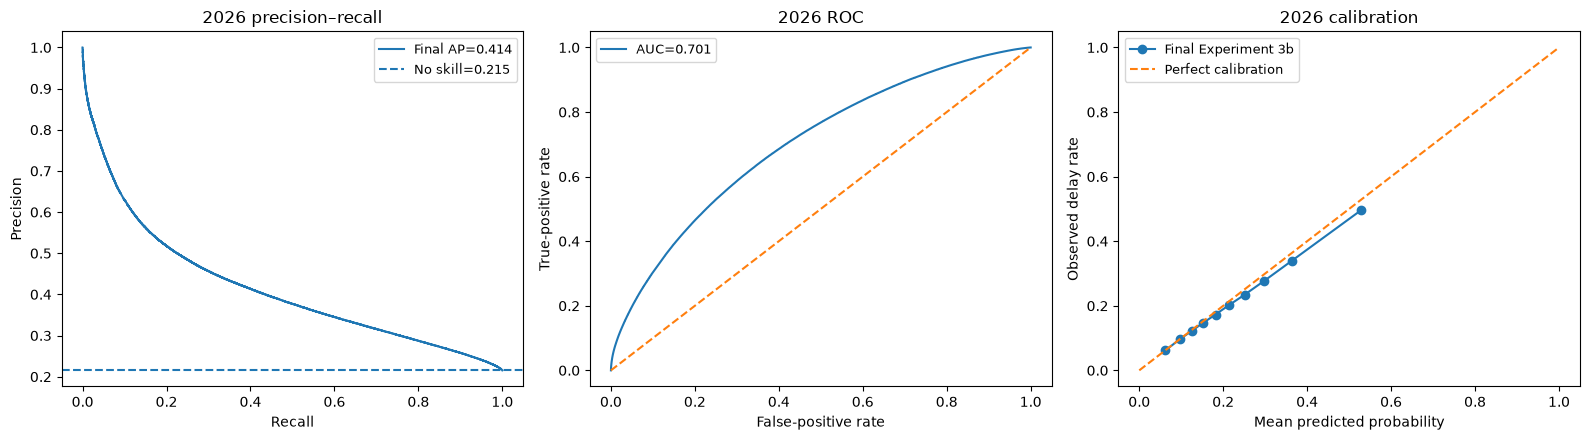

In [17]:
precision, recall, _ = precision_recall_curve(y_test, p_test)
fpr, tpr, _ = roc_curve(y_test, p_test)
frac_pos, mean_pred = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(
    recall,
    precision,
    label=f"Final AP={final_metrics.loc['Final Experiment 3b', 'PR_AUC']:.3f}",
)
axes[0].axhline(
    y_test.mean(),
    linestyle="--",
    label=f"No skill={y_test.mean():.3f}",
)
axes[0].set(xlabel="Recall", ylabel="Precision", title="2026 precision–recall")
axes[0].legend(fontsize=9)

axes[1].plot(
    fpr,
    tpr,
    label=f"AUC={final_metrics.loc['Final Experiment 3b', 'ROC_AUC']:.3f}",
)
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="2026 ROC",
)
axes[1].legend(fontsize=9)

axes[2].plot(mean_pred, frac_pos, marker="o", label="Final Experiment 3b")
axes[2].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
axes[2].set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2026 calibration",
)
axes[2].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / "04_final_2026_validation_curves.png", bbox_inches="tight")
plt.show()

## 9. Frozen-threshold evaluation

The threshold is carried forward unchanged from 2025. Do not maximize F1 again
on 2026.

In [18]:
def threshold_metrics(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    threshold: float,
) -> dict[str, float | int]:
    pred = np.asarray(probabilities) >= threshold
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        "threshold": threshold,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "predicted_positive_rate": pred.mean(),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
    }


frozen_threshold_result = pd.DataFrame([
    threshold_metrics(y_test, p_test, frozen_threshold)
])
print(f"Frozen threshold from 2025: {frozen_threshold:.3f}")
print(frozen_threshold_result.round(4).to_string(index=False))

Frozen threshold from 2025: 0.217
 threshold  precision  recall  specificity  predicted_positive_rate     TP     FP     FN      TN
    0.2171     0.3259  0.6653       0.6223                   0.4397 403186 833947 202878 1373795


## 10. Fixed alert-volume diagnostics

These diagnostics compare ranking performance at fixed operational capacity.
They are not used to select a new 2026 threshold.

In [19]:
def alert_volume_metrics(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    fraction: float,
) -> dict[str, float | int]:
    y_array = np.asarray(y)
    p_array = np.asarray(probabilities)
    n_flag = max(1, int(np.ceil(len(y_array) * fraction)))
    idx = np.argpartition(p_array, -n_flag)[-n_flag:]
    flagged_y = y_array[idx]
    cutoff = float(p_array[idx].min())
    positives = y_array.sum()

    return {
        "alert_fraction": fraction,
        "flights_flagged": n_flag,
        "score_cutoff": cutoff,
        "precision": float(flagged_y.mean()),
        "delay_capture": float(flagged_y.sum() / positives) if positives else np.nan,
    }


alert_volume_table = pd.DataFrame([
    alert_volume_metrics(y_test, p_test, fraction)
    for fraction in (0.05, 0.10, 0.20, 0.30)
])
print(alert_volume_table.round(4).to_string(index=False))

 alert_fraction  flights_flagged  score_cutoff  precision  delay_capture
           0.05           140691        0.4905     0.5794         0.1345
           0.10           281381        0.4100     0.4964         0.2305
           0.20           562762        0.3264     0.4182         0.3883
           0.30           844142        0.2728     0.3713         0.5172


## 11. Monthly Jan–May 2026 stability

 period  flights  actual_rate  mean_prediction  calibration_gap  PR_AUC  ROC_AUC  Brier  pr_auc_lift  brier_skill  frozen_threshold_precision  frozen_threshold_recall  frozen_threshold_alert_rate
2026-01   518165       0.2092           0.2154           0.0062  0.4136   0.6921 0.1493       1.9769       0.0975                      0.3228                   0.6094                       0.3950
2026-02   503293       0.1990           0.2102           0.0112  0.3923   0.6970 0.1446       1.9716       0.0930                      0.3168                   0.6061                       0.3807
2026-03   594090       0.2455           0.2390          -0.0065  0.4606   0.7051 0.1648       1.8760       0.1101                      0.3583                   0.6966                       0.4774
2026-04   592374       0.2036           0.2125           0.0089  0.3845   0.7008 0.1476       1.8888       0.0893                      0.3206                   0.6325                       0.4016
2026-05   605884    

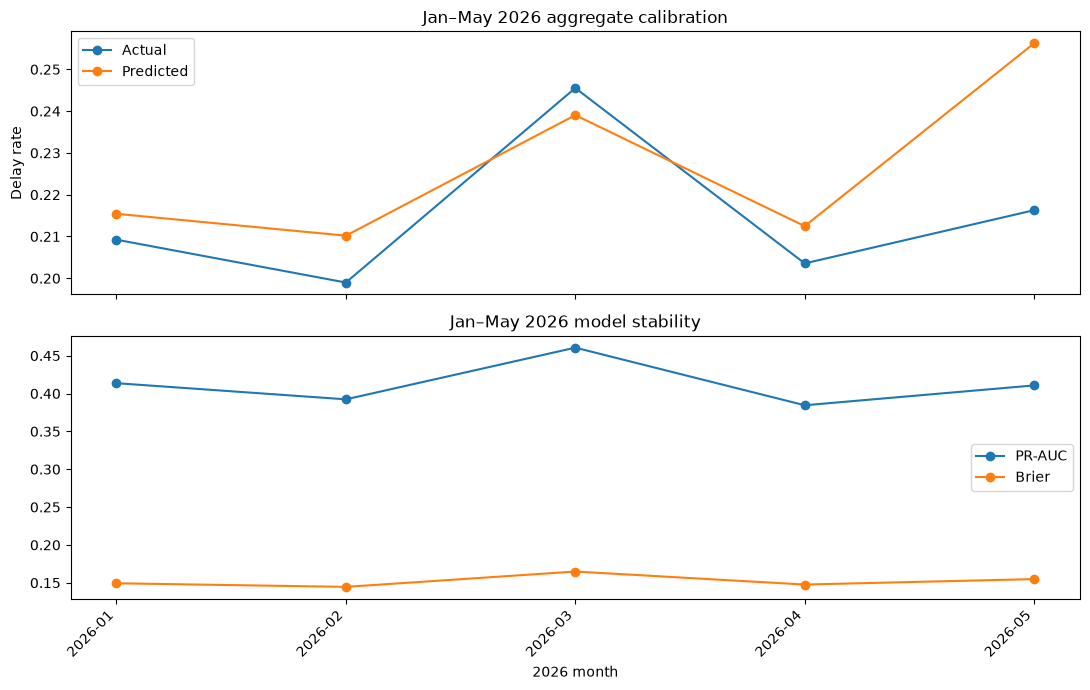

In [20]:
test_results = test_meta.assign(
    y_true=np.asarray(y_test),
    p_delay=p_test,
    predicted_delay=(p_test >= frozen_threshold).astype("int8"),
)
test_results["period"] = (
    pd.to_datetime(test_results["FlightDate"])
    .dt.to_period("M")
    .astype(str)
)

monthly_rows: list[dict[str, str | int | float]] = []
for period, group in test_results.groupby("period", observed=True):
    actual_rate = float(group["y_true"].mean())
    brier = brier_score_loss(group["y_true"], group["p_delay"])
    baseline_brier = actual_rate * (1 - actual_rate)

    monthly_rows.append({
        "period": period,
        "flights": len(group),
        "actual_rate": actual_rate,
        "mean_prediction": group["p_delay"].mean(),
        "calibration_gap": group["p_delay"].mean() - actual_rate,
        "PR_AUC": average_precision_score(group["y_true"], group["p_delay"]),
        "ROC_AUC": roc_auc_score(group["y_true"], group["p_delay"]),
        "Brier": brier,
        "pr_auc_lift": average_precision_score(group["y_true"], group["p_delay"]) / actual_rate,
        "brier_skill": 1 - brier / baseline_brier,
        "frozen_threshold_precision": precision_score(
            group["y_true"],
            group["predicted_delay"],
            zero_division=0,
        ),
        "frozen_threshold_recall": recall_score(
            group["y_true"],
            group["predicted_delay"],
            zero_division=0,
        ),
        "frozen_threshold_alert_rate": group["predicted_delay"].mean(),
    })

monthly = pd.DataFrame(monthly_rows)
print(monthly.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["actual_rate"], marker="o", label="Actual")
axes[0].plot(monthly["period"], monthly["mean_prediction"], marker="o", label="Predicted")
axes[0].set(ylabel="Delay rate", title="Jan–May 2026 aggregate calibration")
axes[0].legend()

axes[1].plot(monthly["period"], monthly["PR_AUC"], marker="o", label="PR-AUC")
axes[1].plot(monthly["period"], monthly["Brier"], marker="o", label="Brier")
axes[1].set(xlabel="2026 month", title="Jan–May 2026 model stability")
axes[1].legend()

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "04_final_2026_monthly_validation.png", bbox_inches="tight")
plt.show()

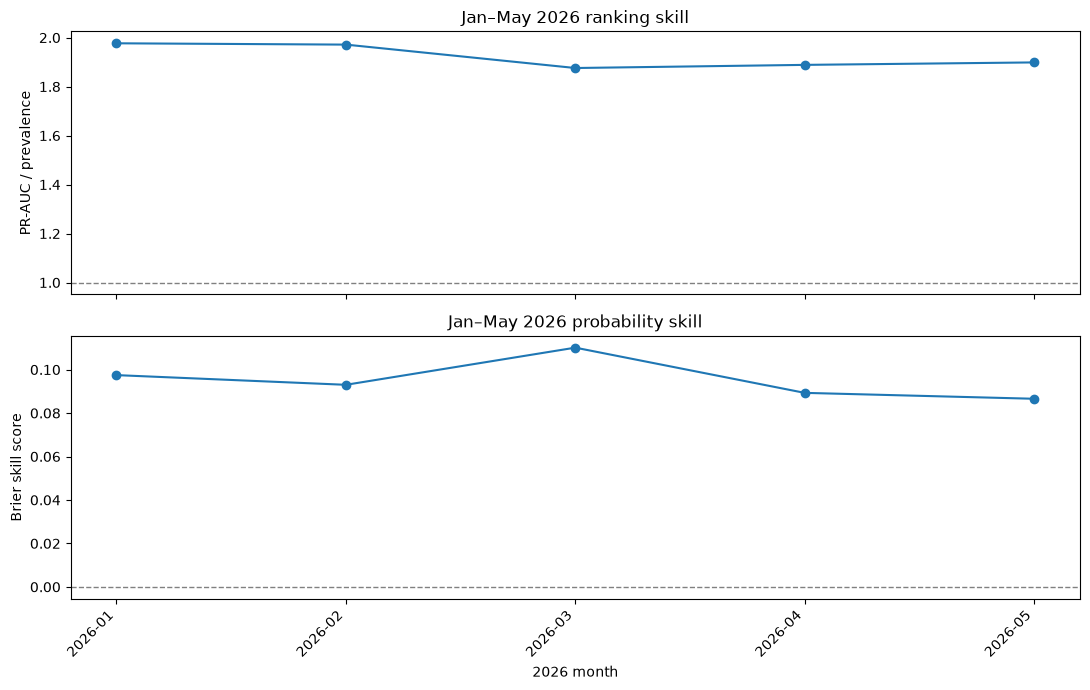

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["pr_auc_lift"], marker="o")
axes[0].axhline(1, color="grey", linestyle="--", linewidth=1)
axes[0].set(
    ylabel="PR-AUC / prevalence",
    title="Jan–May 2026 ranking skill",
)

axes[1].plot(monthly["period"], monthly["brier_skill"], marker="o")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set(
    xlabel="2026 month",
    ylabel="Brier skill score",
    title="Jan–May 2026 probability skill",
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "04_final_2026_monthly_skill.png", bbox_inches="tight")
plt.show()

## 12. Save final-test artifacts

Save the final retrained model and the exact predictions used for evaluation so
the reported 2026 results can be reproduced without rescoring.

In [30]:
final_model_path = MODELS / f"{FINAL_MODEL_NAME}.json"
final_history_path = MODELS / f"{FINAL_MODEL_NAME}_historical_state.joblib"
final_metadata_path = MODELS / f"{FINAL_MODEL_NAME}_metadata.json"
final_metrics_path = MODELS / f"{FINAL_MODEL_NAME}_test_metrics.csv"
final_monthly_path = MODELS / f"{FINAL_MODEL_NAME}_test_monthly.csv"
final_alert_path = MODELS / f"{FINAL_MODEL_NAME}_alert_volume.csv"
final_predictions_path = MODELS / f"{FINAL_MODEL_NAME}_test_predictions.parquet"

final_model.save_model(final_model_path)
joblib.dump(historical_state, final_history_path)
final_metrics.to_csv(final_metrics_path)
monthly.to_csv(final_monthly_path, index=False)
alert_volume_table.to_csv(final_alert_path, index=False)
test_results.to_parquet(final_predictions_path, index=False)

final_metadata = {
    "development_model": DEVELOPMENT_MODEL_NAME,
    "final_model": FINAL_MODEL_NAME,
    "final_train_years": list(TRAIN_YEARS),
    "final_test_year": TEST_YEAR,
    "final_test_months": list(TEST_MONTHS),
    "features": FEATURES,
    "categorical_features": CATEGORICAL,
    "availability_lag_days": AVAILABILITY_LAG_DAYS,
    "historical_feature_specs": [
        {"name": name, "columns": list(columns), "smoothing": smoothing}
        for name, columns, smoothing in DEFAULT_HISTORICAL_RATE_SPECS
    ],
    "recent_national_windows": list(DEFAULT_NATIONAL_WINDOWS),
    "recent_group_specs": [
        {
            "name": spec.name,
            "columns": list(spec.columns),
            "window_days": spec.window_days,
            "smoothing": spec.smoothing,
        }
        for spec in DEFAULT_RECENT_GROUP_SPECS
    ],
    "pressure_feature": {
        "name": PRESSURE_FEATURE,
        "definition": "national_delay_rate_7d - national_delay_rate_28d",
    },
    "frozen_development_best_iteration": frozen_best_iteration,
    "final_n_estimators": frozen_n_estimators,
    "frozen_2025_threshold": frozen_threshold,
    "xgb_params": FINAL_XGB_PARAMS,
    "test_metrics": final_metrics.loc["Final Experiment 3b"].to_dict(),
}
final_metadata_path.write_text(json.dumps(final_metadata, indent=2))

print(f"Saved final model       : {final_model_path}")
print(f"Saved historical state  : {final_history_path}")
print(f"Saved final metadata    : {final_metadata_path}")
print(f"Saved final metrics     : {final_metrics_path}")
print(f"Saved monthly metrics   : {final_monthly_path}")
print(f"Saved alert diagnostics : {final_alert_path}")
print(f"Saved test predictions  : {final_predictions_path}")

Saved final model       : models/stage1_xgb_2024_2025_to_2026_03b_final.json
Saved historical state  : models/stage1_xgb_2024_2025_to_2026_03b_final_historical_state.joblib
Saved final metadata    : models/stage1_xgb_2024_2025_to_2026_03b_final_metadata.json
Saved final metrics     : models/stage1_xgb_2024_2025_to_2026_03b_final_test_metrics.csv
Saved monthly metrics   : models/stage1_xgb_2024_2025_to_2026_03b_final_test_monthly.csv
Saved alert diagnostics : models/stage1_xgb_2024_2025_to_2026_03b_final_alert_volume.csv
Saved test predictions  : models/stage1_xgb_2024_2025_to_2026_03b_final_test_predictions.parquet
